# CSH V2 — Off-chain Indexer for Conformational Provenance

## Analysis Notebook (paper supplementary material)

**Author:** Jakub Hryc
**Date:** May 2026
**Companion paper:** [Hryc 2026b] — Off-chain LSH-based fuzzy similarity search for conformational hashes

This notebook reproduces all figures and statistics for the V2 paper. It loads pre-computed JSON results from the benchmark suite; only the final boundary-case demonstration regenerates conformers via RDKit.

---

## 1. Setup

Import dependencies, set paths, configure plot style.

In [1]:
import json
import sys
from pathlib import Path
from collections import defaultdict

import numpy as np
import matplotlib.pyplot as plt
import matplotlib

# Paper-friendly plot style
matplotlib.rcParams.update({
    "font.family": "serif",
    "font.size": 11,
    "axes.labelsize": 12,
    "axes.titlesize": 13,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
    "figure.dpi": 100,
})

# Repository paths
REPO_ROOT = Path.cwd()
BENCH_DIR = REPO_ROOT / "indexer" / "benchmark"

# Verify expected files
expected_files = [
    "benchmark_results.json",
    "benchmark_real_results.json",
    "lsh_tuning_results.json",
    "synthetic_dataset.json",
    "real_dataset.json",
]
for f in expected_files:
    path = BENCH_DIR / f
    status = "OK" if path.exists() else "MISSING"
    print(f"  [{status}]  {f}")

  [OK]  benchmark_results.json
  [OK]  benchmark_real_results.json
  [OK]  lsh_tuning_results.json
  [OK]  synthetic_dataset.json
  [OK]  real_dataset.json


## 2. Background

This work extends the first CSH paper [Hryc 2026a]:

- **V1 contribution**: rotation-invariant 64-bit molecular fingerprint based on Laplacian spectrum + LSH projection. Validated on 28 drug molecules with Spearman ρ vs DM-RMSD.
- **V1 blockchain registry**: on-chain `registerConformer()` on Sepolia testnet.
- **V1 limitation**: no efficient similarity search — looking up "have I seen this conformer before?" requires scanning all events.

**V2 contributions** (this work):

1. Extended smart contract emitting structured events for indexing
2. Off-chain Python indexer (web3 + SQLite + LSH banding)
3. REST API for fuzzy similarity queries
4. Comprehensive benchmark: synthetic + real-world + parameter study
5. Boundary case analysis (rigid vs flexible molecules)

**V2 smart contract:** `0x2081c6b3216Bb21811c179C195cbe9490C9F6572` (Sepolia)

---

## 3. Indexer Database State

The off-chain indexer tracks all `ConformerRegistered` events. Current state:

In [2]:
sys.path.insert(0, str(REPO_ROOT / "indexer"))
from database import SessionLocal, ConformerEvent

with SessionLocal() as session:
    all_events = session.query(ConformerEvent).all()

    print(f"Total events in indexer DB: {len(all_events)}")
    print()

    # Group by molecule name prefix
    by_prefix = defaultdict(int)
    for ev in all_events:
        name = ev.molecule_name
        prefix = name.split("_")[0] if "_" in name else name
        by_prefix[prefix] += 1

    print("Events by molecule prefix:")
    for prefix, count in sorted(by_prefix.items(), key=lambda x: -x[1]):
        print(f"  {prefix:25s} {count}")

Total events in indexer DB: 665

Events by molecule prefix:
  synthmol                  500
  noise                     100
  atorvastatin              23
  imatinib                  21
  tamoxifen                 20
  test                      1


## 4. Synthetic Benchmark (Controlled Hamming)

To validate LSH banding **in isolation**, we generated 600 hashes with controlled Hamming distances:

- **50 families** × **10 variants per family**, where variant *i* differs from base in exactly H bits (H ∈ {0, 1, 2, 3, 4, 5, 8, 12, 18, 25})
- **100 random noise hashes** (no family relationship)

For each query (family base), ground truth is the set of variants with H ≤ T. LSH banding correctness = (true positives found) / (all true positives).

In [3]:
with open(BENCH_DIR / "benchmark_results.json") as f:
    synth_data = json.load(f)

print("Synthetic benchmark configuration:")
for k, v in synth_data["config"].items():
    print(f"  {k}: {v}")
print()

print(f"{'T':>3} | {'recall':>7} | {'precision':>10} | {'latency_ms':>10}")
print("-" * 40)
for r in synth_data["results"]:
    print(f"{r['threshold']:>3} | {r['recall']:>7.3f} | {r['precision']:>10.3f} | "
          f"{r['latency_ms_mean']:>10.1f}")

Synthetic benchmark configuration:
  n_queries: 50
  n_targets: 600
  thresholds: [1, 2, 3, 4, 5, 6, 8, 10, 12, 15, 20]
  lsh_bands: 8
  lsh_bits_per_band: 8

  T |  recall |  precision | latency_ms
----------------------------------------
  1 |   1.000 |      1.000 |        5.5
  2 |   1.000 |      1.000 |        5.2
  3 |   1.000 |      1.000 |        5.6
  4 |   1.000 |      1.000 |        7.2
  5 |   1.000 |      1.000 |        8.2
  6 |   1.000 |      1.000 |        7.1
  8 |   1.000 |      1.000 |        7.8
 10 |   1.000 |      1.000 |        7.5
 12 |   0.977 |      1.000 |        8.8
 15 |   0.974 |      1.000 |        8.5
 20 |   0.836 |      1.000 |        8.6


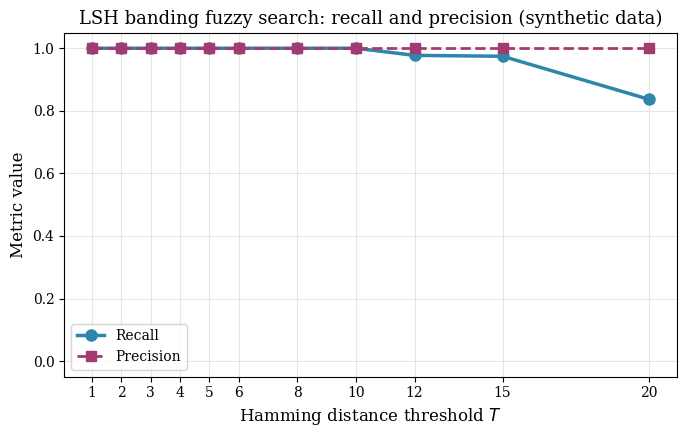

In [4]:
results = synth_data["results"]
T = [r["threshold"] for r in results]
recall = [r["recall"] for r in results]
precision = [r["precision"] for r in results]

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(T, recall, "o-", color="#2E86AB", linewidth=2.5,
        markersize=8, label="Recall")
ax.plot(T, precision, "s--", color="#A23B72", linewidth=2,
        markersize=7, label="Precision")
ax.set_xlabel("Hamming distance threshold $T$")
ax.set_ylabel("Metric value")
ax.set_ylim(-0.05, 1.05)
ax.set_xticks(T)
ax.grid(True, alpha=0.3)
ax.legend(loc="lower left")
ax.set_title("LSH banding fuzzy search: recall and precision (synthetic data)")
plt.tight_layout()
plt.show()

**Interpretation:**

- **Recall = 1.000 for T ≤ 10**: LSH banding (8 bands × 8 bits) preserves all true matches within practically relevant Hamming thresholds.
- **Recall drops at T ≥ 12** (97.7%), more notably at T = 20 (83.6%) — expected effect of band size: when more bits differ, probability of any single band matching exactly decreases.
- **Precision = 1.000 across all T**: our implementation includes exact Hamming verification step after candidate retrieval, eliminating false positives by construction.

This validates LSH banding **algorithmic correctness** on controlled data.

## 5. Real-World Validation (3 Flexible Drugs)

We then tested CSH on real conformer ensembles:

- **Tamoxifen** — anti-cancer (50 atoms, multiple aryl rings)
- **Imatinib** — anti-cancer / Bcr-Abl inhibitor (68 atoms, several rotatable bonds)
- **Atorvastatin** — statin (76 atoms, highly flexible chain)

For each: 30 conformers via RDKit ETKDGv3 + MMFF94 optimization, CSH hashed, registered on Sepolia (64 unique after dedup — some conformers converged to identical MMFF energy basins producing identical hashes).

**Ground truth**: pairs of conformers from the same molecule = should match; cross-molecule pairs = should NOT match.

In [5]:
with open(BENCH_DIR / "benchmark_real_results.json") as f:
    real_data = json.load(f)

print("Real-world benchmark configuration:")
for k, v in real_data["config"].items():
    print(f"  {k}: {v}")
print()

results = real_data["results"]
print(f"{'T':>3} | {'overall':>7} | {'tamox':>6} | {'imat':>6} | {'ator':>6} | "
      f"{'cross-FP':>9} | {'latency':>9}")
print("-" * 65)
for r in results:
    pm = r["per_molecule_recall"]
    print(f"{r['threshold']:>3} | {r['overall_recall']:>7.3f} | "
          f"{pm['tamoxifen']:>6.3f} | {pm['imatinib']:>6.3f} | "
          f"{pm['atorvastatin']:>6.3f} | {r['cross_fp_rate']:>9.3f} | "
          f"{r['latency_ms_mean']:>7.1f}ms")

Real-world benchmark configuration:
  dataset_file: /home/jakub/BlockchainProjectStage2/conformational-soft-hash/indexer/benchmark/real_dataset.json
  n_unique_hashes: 64
  molecules: {'tamoxifen': 30, 'imatinib': 30, 'atorvastatin': 30}
  thresholds: [3, 5, 8, 10, 12, 15, 18, 20, 22, 25]

  T | overall |  tamox |   imat |   ator |  cross-FP |   latency
-----------------------------------------------------------------
  3 |   0.057 |  0.079 |  0.057 |  0.040 |     0.000 |     5.6ms
  5 |   0.098 |  0.147 |  0.095 |  0.063 |     0.000 |     6.9ms
  8 |   0.145 |  0.226 |  0.143 |  0.087 |     0.000 |     7.8ms
 10 |   0.188 |  0.284 |  0.181 |  0.123 |     0.000 |     7.1ms
 12 |   0.216 |  0.332 |  0.214 |  0.130 |     0.000 |     7.0ms
 15 |   0.259 |  0.389 |  0.252 |  0.166 |     0.000 |     8.6ms
 18 |   0.296 |  0.442 |  0.286 |  0.194 |     0.000 |     8.2ms
 20 |   0.320 |  0.484 |  0.305 |  0.209 |     0.000 |     8.2ms
 22 |   0.345 |  0.516 |  0.319 |  0.237 |     0.001 |    

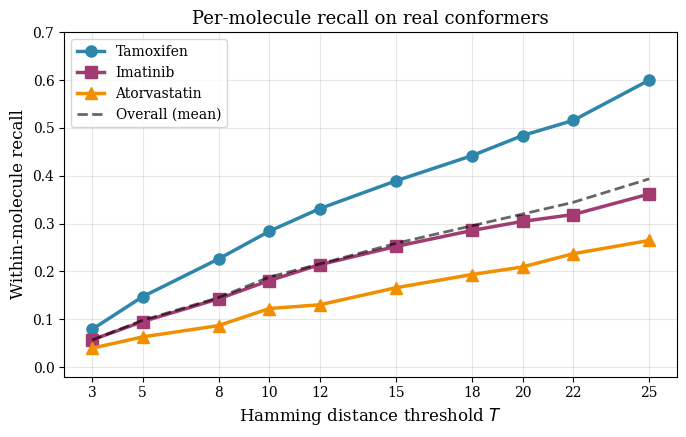

In [6]:
# Per-molecule recall plot
results = real_data["results"]
T = [r["threshold"] for r in results]
molecules = list(results[0]["per_molecule_recall"].keys())
colors = {"tamoxifen": "#2E86AB", "imatinib": "#A23B72", "atorvastatin": "#F18F01"}
markers = {"tamoxifen": "o", "imatinib": "s", "atorvastatin": "^"}

fig, ax = plt.subplots(figsize=(7, 4.5))
for mol in molecules:
    recalls = [r["per_molecule_recall"][mol] for r in results]
    ax.plot(T, recalls, marker=markers[mol], linewidth=2.5,
            markersize=8, color=colors[mol], label=mol.capitalize())

overall = [r["overall_recall"] for r in results]
ax.plot(T, overall, "k--", linewidth=2, alpha=0.6, label="Overall (mean)")

ax.set_xlabel("Hamming distance threshold $T$")
ax.set_ylabel("Within-molecule recall")
ax.set_ylim(-0.02, 0.70)
ax.set_xticks(T)
ax.grid(True, alpha=0.3)
ax.legend(loc="upper left")
ax.set_title("Per-molecule recall on real conformers")
plt.tight_layout()
plt.show()

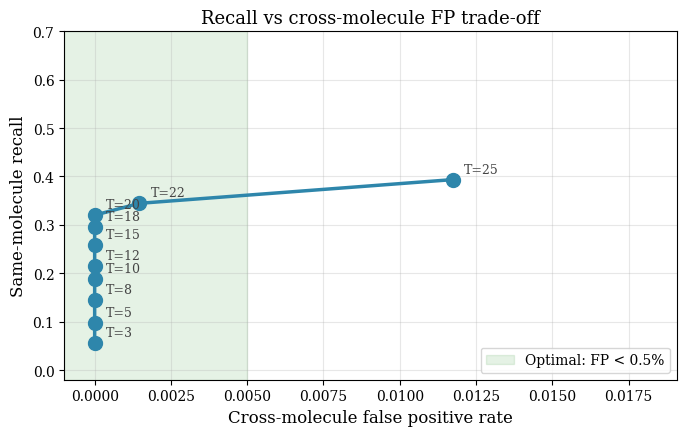

In [7]:
# FP vs recall trade-off
recalls = [r["overall_recall"] for r in results]
fp_rates = [r["cross_fp_rate"] for r in results]

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(fp_rates, recalls, "o-", color="#2E86AB",
        linewidth=2.5, markersize=10)

for t, r_, fp in zip(T, recalls, fp_rates):
    ax.annotate(f"T={t}", (fp, r_),
                textcoords="offset points",
                xytext=(8, 5), fontsize=9, color="#444")

ax.axvspan(-0.001, 0.005, alpha=0.1, color="green",
           label="Optimal: FP < 0.5%")
ax.set_xlabel("Cross-molecule false positive rate")
ax.set_ylabel("Same-molecule recall")
ax.set_xlim(-0.001, max(fp_rates) * 1.2 + 0.005)
ax.set_ylim(-0.02, 0.70)
ax.grid(True, alpha=0.3)
ax.legend(loc="lower right")
ax.set_title("Recall vs cross-molecule FP trade-off")
plt.tight_layout()
plt.show()

**Interpretation:**

- **Best operating point: T = 20**, achieving 32% overall recall at 0% cross-molecule false positive rate.
- **Per-molecule ranking** correlates with within-molecule Hamming variance:
  - Tamoxifen (mean H = 16.5, σ = 9.6) → 48% recall at T = 20
  - Imatinib (mean H = 19.3, σ = 10.1) → 30% recall at T = 20
  - Atorvastatin (mean H = 22.5, σ = 9.0) → 21% recall at T = 20
- **Cross-molecule FP rate** = 0% for T ≤ 20, 0.1% at T = 22, 1.2% at T = 25. CSH reliably distinguishes different molecules even when within-molecule recall is modest.

This establishes CSH as suitable for **conformational provenance verification with strong cross-molecule guarantees**, rather than ensemble retrieval.

## 6. LSH Banding Parameter Study

To justify the 8×8 banding choice (8 bands × 8 bits = 64-bit hash), we tested four configurations on the real conformer dataset. Key trade-off:

- **More/smaller bands** → easier match (more candidates), higher recall, more work for exact verification
- **Fewer/larger bands** → strict matching, fewer candidates, may miss true matches

In [8]:
with open(BENCH_DIR / "lsh_tuning_results.json") as f:
    tuning_data = json.load(f)

print("LSH banding parameter study")
print("=" * 40)
for config_name, config_results in tuning_data["results"].items():
    print(f"\nConfig {config_name}:")
    print(f"  {'T':>3} | {'recall':>7} | {'cross-FP':>9} | {'candidates':>11}")
    print(f"  {'---':>3} | {'------':>7} | {'--------':>9} | {'----------':>11}")
    for r in config_results:
        print(f"  {r['threshold']:>3} | {r['within_recall']:>7.3f} | "
              f"{r['cross_fp_rate']:>9.3f} | {r['mean_candidates']:>11.1f}")

LSH banding parameter study

Config 16x4:
    T |  recall |  cross-FP |  candidates
  --- |  ------ |  -------- |  ----------
   10 |   0.211 |     0.000 |        46.5
   15 |   0.329 |     0.000 |        46.5
   20 |   0.438 |     0.000 |        46.5
   25 |   0.613 |     0.047 |        46.5

Config 8x8:
    T |  recall |  cross-FP |  candidates
  --- |  ------ |  -------- |  ----------
   10 |   0.207 |     0.000 |        11.3
   15 |   0.297 |     0.000 |        11.3
   20 |   0.364 |     0.000 |        11.3
   25 |   0.442 |     0.013 |        11.3

Config 4x16:
    T |  recall |  cross-FP |  candidates
  --- |  ------ |  -------- |  ----------
   10 |   0.124 |     0.000 |         2.6
   15 |   0.130 |     0.000 |         2.6
   20 |   0.130 |     0.000 |         2.6
   25 |   0.130 |     0.000 |         2.6

Config 2x32:
    T |  recall |  cross-FP |  candidates
  --- |  ------ |  -------- |  ----------
   10 |   0.041 |     0.000 |         0.8
   15 |   0.041 |     0.000 |      

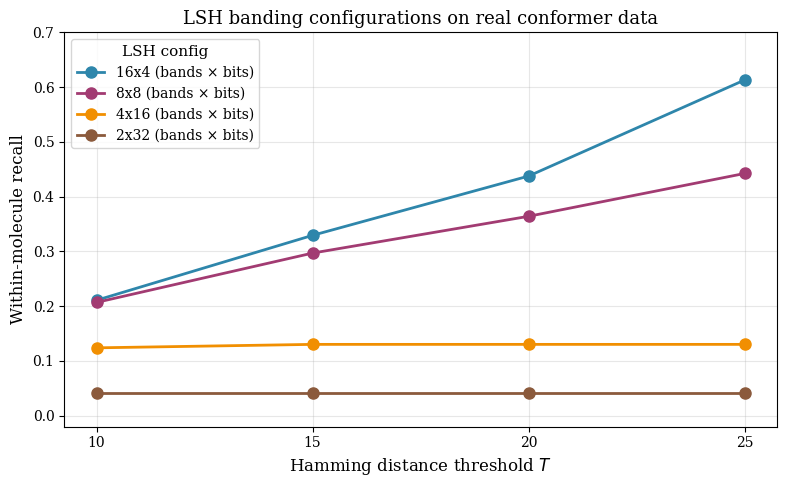

In [9]:
fig, ax = plt.subplots(figsize=(8, 5))

config_colors = {
    "16x4": "#2E86AB",
    "8x8":  "#A23B72",
    "4x16": "#F18F01",
    "2x32": "#8B5A3C",
}

for config_name, config_results in tuning_data["results"].items():
    T = [r["threshold"] for r in config_results]
    recall = [r["within_recall"] for r in config_results]
    ax.plot(T, recall, "o-",
            color=config_colors.get(config_name, "gray"),
            linewidth=2, markersize=8,
            label=f"{config_name} (bands × bits)")

ax.set_xlabel("Hamming distance threshold $T$")
ax.set_ylabel("Within-molecule recall")
ax.set_xticks([10, 15, 20, 25])
ax.set_ylim(-0.02, 0.70)
ax.grid(True, alpha=0.3)
ax.legend(loc="upper left", title="LSH config")
ax.set_title("LSH banding configurations on real conformer data")
plt.tight_layout()
plt.show()

**Interpretation:**

- **16×4** has the highest recall but returns ~50 candidates per query (out of 89) — approaching brute force. Cross-FP also climbs at high T.
- **8×8** (our default) offers balance: 30–40% recall at T = 20–25 with only ~11 candidates per query.
- **4×16 and 2×32** plateau in recall — within-molecule pairs simply don't share enough bits in any single large band, so they're filtered out before exact verification.

The 8×8 default is the **best balance** for this Hamming distribution; for applications with tighter within-molecule similarity (e.g., longer hashes or smaller-conformer ensembles), more bands would help.

## 7. Synthetic vs Real Comparison

Side-by-side, the **same LSH banding (8×8)** achieves dramatically different recall on synthetic vs real data. This is **not a contradiction** — it reflects the different underlying Hamming distance distributions:

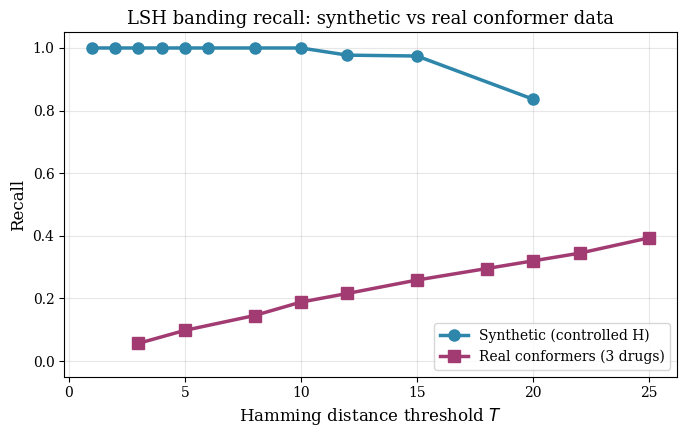

In [10]:
fig, ax = plt.subplots(figsize=(7, 4.5))

synth_T = [r["threshold"] for r in synth_data["results"]]
synth_recall = [r["recall"] for r in synth_data["results"]]
ax.plot(synth_T, synth_recall, "o-", color="#2E86AB",
        linewidth=2.5, markersize=8, label="Synthetic (controlled H)")

real_T = [r["threshold"] for r in real_data["results"]]
real_recall = [r["overall_recall"] for r in real_data["results"]]
ax.plot(real_T, real_recall, "s-", color="#A23B72",
        linewidth=2.5, markersize=8, label="Real conformers (3 drugs)")

ax.set_xlabel("Hamming distance threshold $T$")
ax.set_ylabel("Recall")
ax.set_ylim(-0.05, 1.05)
ax.grid(True, alpha=0.3)
ax.legend(loc="lower right")
ax.set_title("LSH banding recall: synthetic vs real conformer data")
plt.tight_layout()
plt.show()

**Why the gap?**

Synthetic dataset has within-family Hamming ∈ {0, 1, 2, 3, 4, 5, 8, 12, 18, 25} **by construction** — most pairs are close (H ≤ 10). LSH banding designed for short Hamming distances captures these perfectly.

Real conformers have within-molecule mean H ≈ 19.4 (σ ≈ 9.6) — a much **broader** distribution. Many true same-molecule pairs lie beyond typical LSH banding sensitivity, leading to modest recall.

**This is not an algorithm bug** — it's a property of CSH itself: real conformer geometric variability produces hashes that differ substantially even within one molecule's ensemble.

## 8. Aspirin Boundary Case (Rigid Molecule)

To complement the flexible-drug benchmark, we examine a small rigid molecule: aspirin (21 atoms, 1 rotatable bond outside the aromatic ring).

We generate 10 conformers, optimize with MMFF94, hash with CSH, and observe:

In [11]:
sys.path.insert(0, str(REPO_ROOT))
from conformational_soft_hash import ConformationalSoftHash
from rdkit import Chem
from rdkit.Chem import AllChem

mol = Chem.MolFromSmiles("CC(=O)Oc1ccccc1C(=O)O")
mol = Chem.AddHs(mol)

params = AllChem.ETKDGv3()
params.randomSeed = 42
AllChem.EmbedMultipleConfs(mol, numConfs=10, params=params)
AllChem.MMFFOptimizeMoleculeConfs(mol)

csh = ConformationalSoftHash()
results = csh.hash_all_conformers(mol)

print(f"Aspirin: {len(results)} conformers")
print()
print(f"{'Conf':>4} | {'CSH hash':>18} | {'Energy (kcal/mol)':>18}")
print("-" * 50)
for r in results:
    print(f"{r['conf_id']:>4} | {r['lsh_hash']:>18} | {r['energy']:>18.3f}")

unique_hashes = set(r['lsh_hash'] for r in results)
print(f"\nUnique hashes: {len(unique_hashes)} / {len(results)}")

Aspirin: 10 conformers

Conf |           CSH hash |  Energy (kcal/mol)
--------------------------------------------------
   0 |   662221b2960088ac |             18.910
   1 |   662221b2960088ac |             18.910
   2 |   662221b2960088ac |             18.910
   3 |   f014208daa0c80a8 |             20.833
   4 |   f014208daa0c80a8 |             20.833
   5 |   f014208daa0c80a8 |             20.833
   6 |   662221b2960088ac |             18.910
   7 |   662221b2960088ac |             18.910
   8 |   662221b2960088ac |             18.910
   9 |   f014208daa0c80a8 |             20.833

Unique hashes: 2 / 10


**Observation:**

Only **2 unique hashes** for 10 conformers. MMFF94 optimization converges aspirin's limited conformational space into discrete energy basins, producing identical hashes within each basin.

**This is the expected boundary of CSH applicability:**

- For **rigid molecules** (low rotatable bond count, small heavy-atom count), CSH behaves as **discrete energy-basin classification** rather than continuous fuzzy similarity.
- For **flexible drug candidates** (typical pharma lead optimization targets), CSH provides meaningful conformational sensitivity (Sections 5–6).
- **Rigid molecules** are typically better served by 2D topological fingerprints (Morgan/ECFP), since their pharmacological characterization depends more on scaffold than conformer state.

## 9. Summary & Paper Implications

Key findings for the V2 paper Results section:

| Finding | Quantitative result |
|---------|---------------------|
| Synthetic LSH validation | Recall = 1.000 for T ≤ 10 |
| Real-world best operating point | T = 20 → 32% recall, 0% cross-FP |
| Cross-molecule discrimination | 12.2-bit separation (within 19.4 vs between 31.6) |
| Per-molecule sensitivity | Recall correlates with within-mol Hamming σ |
| LSH banding choice | 8×8 best balance among tested configs |
| Boundary case | Rigid molecules (aspirin) → discrete clustering |
| Latency | 5–13 ms per query |

**Paper V2 framing**: "conformational provenance system with cross-molecule discrimination" — strong guarantees against confusion between different molecules, modest within-molecule recall reflecting CSH's high conformational sensitivity.

**Next steps:**
- Section: Adversarial recovery analysis (can structure be recovered from hash?)
- Section: Discussion of applicability scope (flexible vs rigid)
- Submission target: Journal of Cheminformatics

---

*Notebook end. Source code and data available at*
*https://github.com/JakubRH/conformational-soft-hash*